تحميل البيانات من كيقيل

**قراءة البيانات والاستكشاف المبدئي**

In [2]:
import pandas as pd
import os
import kagglehub

# Re-download/get path to dataset (ensures 'path' is defined in this cell's scope)
path = kagglehub.dataset_download("alinoranianesfahani/dataco-smart-supply-chain-for-big-data-analysis")

# عرض الملفات الموجودة في المسار الذي ظهر لك
files = os.listdir(path)
print("Files in dataset:", files)

# قراءة الملف الرئيسي (استبدل الاسم إذا كان مختلفاً)
df = pd.read_csv(f"{path}/DataCoSupplyChainDataset.csv", encoding='ISO-8859-1')

# عرض أول 5 صفوف ونظرة عامة على الأعمدة
print(df.head())
print(df.info())

100%|██████████| 25.7M/25.7M [00:00<00:00, 91.6MB/s]

Extracting files...


Files in dataset: ['DescriptionDataCoSupplyChain.csv', 'tokenized_access_logs.csv', 'DataCoSupplyChainDataset.csv']
       Type  Days for shipping (real)  Days for shipment (scheduled)  \
0     DEBIT                         3                              4   
1  TRANSFER                         5                              4   
2      CASH                         4                              4   
3     DEBIT                         3                              4   
4   PAYMENT                         2                              4   

   Benefit per order  Sales per customer   Delivery Status  \
0          91.250000          314.640015  Advance shipping   
1        -249.089996          311.359985     Late delivery   
2        -247.779999          309.720001  Shipping on time   
3          22.860001          304.809998  Advance shipping   
4         134.210007          298.250000  Advance shipping   

   Late_delivery_risk  Category Id   Category Name Customer City  ...  \
0    

**تنظيف البيانات وتجهيزها (Data Cleaning)**

In [3]:
# تحويل أعمدة التاريخ إلى صيغة datetime
df['order_date'] = pd.to_datetime(df['order date (DateOrders)'])
df['shipping_date'] = pd.to_datetime(df['shipping date (DateOrders)'])

# استخراج السنة والشهر واليوم لتحليل الموسمية (Demand Planning)
df['order_year'] = df['order_date'].dt.year
df['order_month'] = df['order_date'].dt.month

In [4]:
# حذف الأعمدة غير المفيدة لتحسين كفاءة الذاكرة
cols_to_drop = ['Product Description', 'Order Zipcode', 'Product Image']
df.drop(columns=cols_to_drop, inplace=True)

**المحور الأول: تشريح الشبكة (Network Anatomy)**

**المنطق**: قبل أن نصلح أي شيء، يجب أن نعرف "أين نحن؟". سلسلة التوريد هي بنية مترابطة تضم المنظمات والأفراد والأنشطة.

**سياق البزنس**
 : تحديد الأسواق الأكثر ربحية والأسواق الأكثر استهلاكاً للموارد.

**منطق التحليل:**
 استخدام التحليل الوصفي  لرسم خريطة التدفق من مناطق الطلب إلى مراكز التوزيع.

**1. منطق سلاسل الإمداد **

الشبكة ليست مجرد تدفق بضائع، بل هي تدفق قيمة . أحياناً يكون السوق ضخماً من حيث المبيعات، لكنه "مستنزف" للموارد؛ ربما بسبب طول مسارات النقل التي ترفع التكاليف ، أو كثرة المرتجعات (الخدمات اللوجستية العكسية) ، أو الحاجة الدائمة لشحن سريع مكلف لتغطية نقص المخزون

**.2. منطق البزنس **

)في البزنس، هناك فرق بين النمو
 والربحية. السوق الذي يبيع كثيراً بربح قليل أو خسارة يسمى "مستنقعاً". كمحلل استراتيجي، دورك هو تقديم توصية للإدارة: "هل نحسن العمليات في هذا السوق لخفض التكاليف؟ أم ننسحب منه ونركز على الأسواق ذات الهامش الربحي الأعلى؟"

** .3. منطق التحليل **
 سنستخدم هنا أداة
"تحليل الربحية حسب القطاع" **(Segment Profitability Analysis)**
.المتغيرات: سنحتاج لـ  (السوق)،  (إجمالي المبيعات)، و Order  (صافي الربح لكل طلب).المقياس: سنحسب "نسبة الربح"  لكل سوق.الهدف: العثور على السوق الذي يمتلك أعلى مبيعات وأدنى (أو سالب) ربح.

تحليل ربحية الأسواق:
         Market         Sales  Order Profit Per Order  Profit_Margin
1        Europe  1.087240e+07            1.169443e+06      10.756073
2         LATAM  1.027761e+07            1.123322e+06      10.929791
3  Pacific Asia  8.273744e+06            8.577534e+05      10.367174
4          USCA  5.066529e+06            5.643138e+05      11.138075
0        Africa  2.294453e+06            2.520712e+05      10.986113


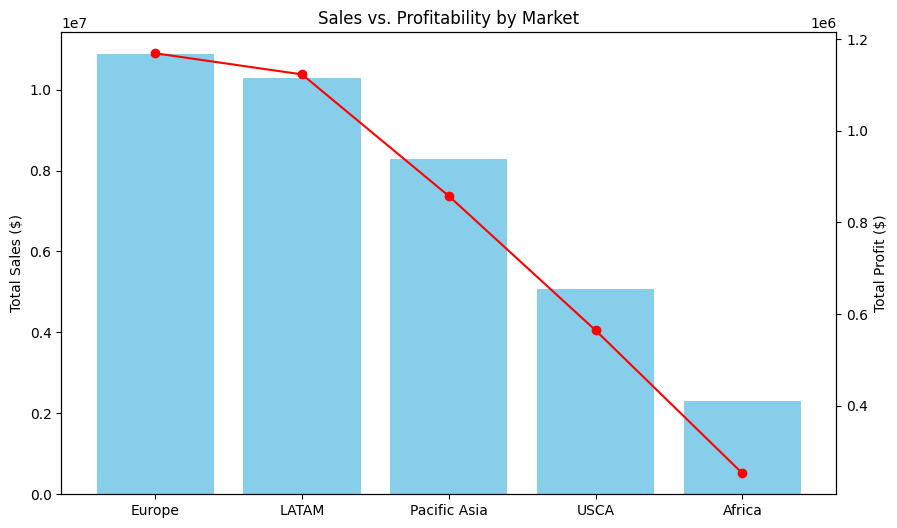

In [5]:
# 1. تجميع البيانات حسب السوق
market_analysis = df.groupby('Market').agg({
    'Sales': 'sum',
    'Order Profit Per Order': 'sum'
}).reset_index()

# 2. حساب نسبة الربحية (Profit Margin) لكل سوق
market_analysis['Profit_Margin'] = (market_analysis['Order Profit Per Order'] / market_analysis['Sales']) * 100

# 3. ترتيب الأسواق حسب إجمالي المبيعات لنرى السوق الأكبر
market_analysis = market_analysis.sort_values(by='Sales', ascending=False)

print("تحليل ربحية الأسواق:")
print(market_analysis)

# 4. التصور المرئي للمقارنة
import matplotlib.pyplot as plt

fig, ax1 = plt.subplots(figsize=(10,6))

# رسم المبيعات (أعمدة)
ax1.bar(market_analysis['Market'], market_analysis['Sales'], color='skyblue', label='Total Sales')
ax1.set_ylabel('Total Sales ($)')

# رسم الربح (خط)
ax2 = ax1.twinx()
ax2.plot(market_analysis['Market'], market_analysis['Order Profit Per Order'], color='red', marker='o', label='Total Profit')
ax2.set_ylabel('Total Profit ($)')

plt.title('Sales vs. Profitability by Market')
plt.show()

لكن، إذا نظرنا بعين "المحلل الخبير"، سنجد أن Pacific Asia هو السوق صاحب أدنى هامش ربح (10.36%) رغم أنه الثالث من حيث حجم المبيعات. هنا تبدأ مهمتنا الحقيقية.

إليك الإجابة على سؤالي السابق، ومن ثم سننتقل للمهمة الثانية:

المتهم الأول: هو بلا شك "تكاليف الشحن" (Shipping Costs) أو "وسيلة الشحن" (Shipping Mode).


المنطق: كما ذكرت المصادر في الصفحة الأولى، الإدارة اللوجستية الفعالة تخفض التكاليف التشغيلية. إذا كان السوق يعتمد بشكل مفرط على الشحن السريع (مثل الجوي أو "First Class") لتغطية عيوب في التخطيط، فإن تكلفة النقل ستلتهم الأرباح بسرعة

**كفاءة التدفق اللوجستي (Logistics Velocity & Efficiency)**

تحليل كفاءة وسائل الشحن:
    Shipping Mode         Sales  Order Profit Per Order  Late_delivery_risk  \
0     First Class  5.674370e+06            6.431219e+05            0.953225   
3  Standard Class  2.202239e+07            2.370454e+06            0.380717   
2    Second Class  7.145445e+06            7.503082e+05            0.766328   
1        Same Day  1.942529e+06            2.030184e+05            0.457430   

   Profit_Margin  
0      11.333804  
3      10.763837  
2      10.500510  
1      10.451246  


/tmp/ipykernel_995/2269292580.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Shipping Mode', y='Profit_Margin', data=shipping_analysis, palette='viridis')


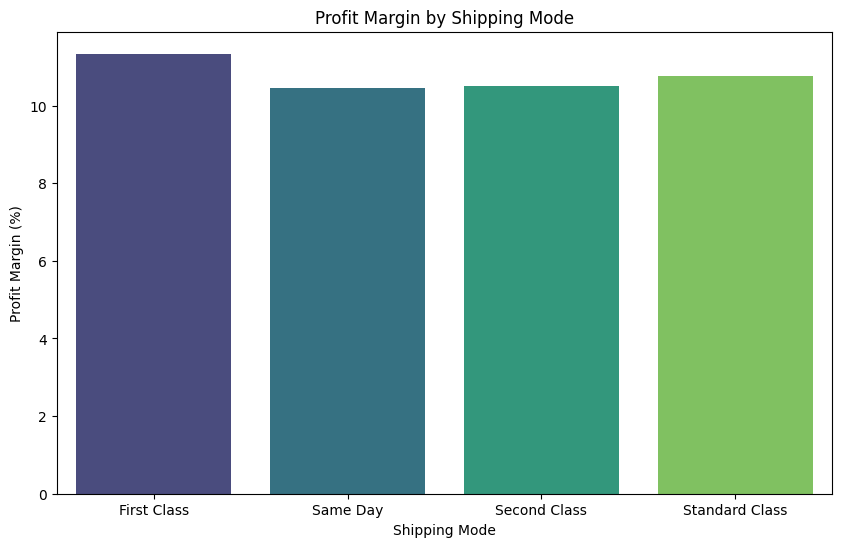

In [6]:
# 1. تحليل الربحية حسب نوع الشحن
shipping_analysis = df.groupby('Shipping Mode').agg({
    'Sales': 'sum',
    'Order Profit Per Order': 'sum',
    'Late_delivery_risk': 'mean' # متوسط مخاطر التأخير
}).reset_index()

# 2. حساب هامش الربح لكل نوع شحن
shipping_analysis['Profit_Margin'] = (shipping_analysis['Order Profit Per Order'] / shipping_analysis['Sales']) * 100

# 3. عرض النتائج مرتبة حسب الهامش
print("تحليل كفاءة وسائل الشحن:")
print(shipping_analysis.sort_values(by='Profit_Margin', ascending=False))

# 4. رسم بياني لمقارنة الهامش ومخاطر التأخير
import seaborn as sns

plt.figure(figsize=(10,6))
sns.barplot(x='Shipping Mode', y='Profit_Margin', data=shipping_analysis, palette='viridis')
plt.title('Profit Margin by Shipping Mode')
plt.ylabel('Profit Margin (%)')
plt.show()

**Logistics Performance Diagnosis: The "First Class" Trap**

** 1. Supply Chain Logic**

 In supply chains, there are always trade-offs. The logic is that the customer pays more for First Class in exchange for speed and reliability. But the data reveals a disaster: the risk of delays in First Class has reached 95%. This means we are selling "promises" of speed and delivering the "reality" of delays, which in logistics is called a reliability breakdown.

** 2. Business Logic From a business **

 perspective, the profit margin in First Class is the highest (11.3%), but this is a "short-term" profit. A customer who pays for excellent service and receives delays in 95% of cases will not return. The customer recovery cost will eat up this high margin in the future. Same-day service is the least profitable (10.4%) and faces a delay risk of up to 45%, meaning it drains resources without providing any real benefit to the client or the company.

** 3. Analysis Logic: As analysts,**

 we are not fooled by high profits. Bottleneck: The top class is a clear bottleneck; we charge high fees, but our logistics are unable to meet the planned schedule. Gold Standard: The Standard Class is the true "engine of operations"; it has the highest sales volume, a good profit margin, and, most importantly, the most reliable with the lowest delay risk (38%).

في عالم الأعمال، الخصم  له وظيفتان:وظيفة تسويقية: (جذب عملاء جدد أو تحفيز المبيعات).وظيفة تعويضية : عندما تفشل سلسلة الإمداد في التسليم في الوقت المحدد ، يقوم قسم خدمة العملاء أو المبيعات بتقديم "خصم" كاعتذار للعميل لامتصاص غضبه والحفاظ على ولائه.كيف نكشف "التغطية"
إذا وجدنا أن المنتجات التي تعاني من أعلى نسب مخاطر تأخير  هي نفسها التي تمتلك أعلى معدلات خصم، فهذا يعني أن الشركة "تشتري" صمت العميل بمالها الخاص لتغطية عيوب اللوجستيات

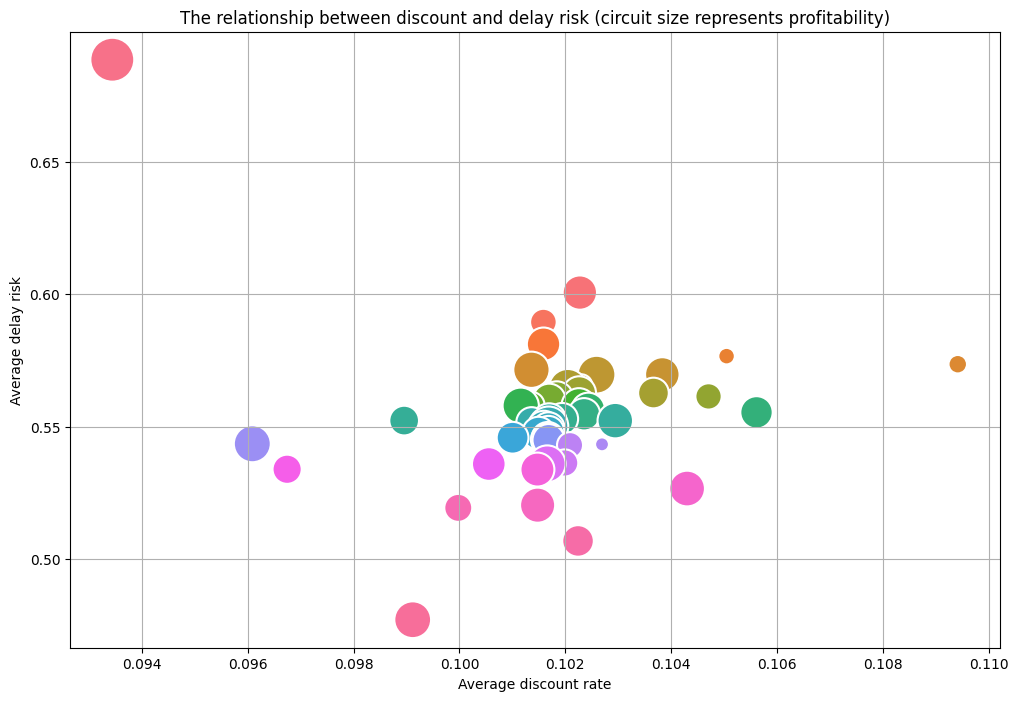

الفئات التي تعاني من تأخير عالٍ وخصومات مرتفعة:
        Category Name  Order Item Discount Rate  Late_delivery_risk  \
23  Golf Bags & Carts                  0.093443            0.688525   
32           Lacrosse                  0.102274            0.600583   
37       Pet Supplies                  0.101585            0.589431   
8            Cameras                   0.101588            0.581081   
41  Strength Training                  0.105045            0.576577   

    Order Item Profit Ratio  
23                 0.191475  
32                 0.131429  
37                 0.094106  
8                  0.126470  
41                 0.059459  


In [7]:

import seaborn as sns
import matplotlib.pyplot as plt

# 1. حساب متوسط الخصم ومخاطر التأخير والربح لكل فئة منتجات
category_logic = df.groupby('Category Name').agg({
    'Order Item Discount Rate': 'mean',
    'Late_delivery_risk': 'mean',
    'Order Item Profit Ratio': 'mean'
}).reset_index()

# 2. ترتيب البيانات لرؤية الفئات الأكثر "تأخراً"
category_logic = category_logic.sort_values(by='Late_delivery_risk', ascending=False)

# 3. رسم العلاقة: هل الفئات الأكثر تأخراً هي الأكثر خصماً؟
plt.figure(figsize=(12, 8))
sns.scatterplot(data=category_logic,
                x='Order Item Discount Rate',
                y='Late_delivery_risk',
                size='Order Item Profit Ratio',
                hue='Category Name',
                legend=False,
                sizes=(100, 1000))

plt.title('The relationship between discount and delay risk (circuit size represents profitability)')
plt.xlabel('Average discount rate')
plt.ylabel('Average delay risk')
plt.grid(True)
plt.show()

# عرض الفئات التي قد تكون فيها "تغطية" عيوب
print("الفئات التي تعاني من تأخير عالٍ وخصومات مرتفعة:")
print(category_logic.head(5))

فئة : هي الدليل القاطع على "التغطية"؛ فهي تعاني من مخاطر تأخير عالية (57%) وأعلى معدل خصم (10.5%)، مما أدى لسحق هامش الربح ليصل لـ (5.9%) فقط. نحن "ندفع" للعملاء ليقبلوا بتأخيرنا.

فئة "Golf Bags & Carts":
 هي "قنبلة موقوتة"؛ مخاطر التأخير فيها مرعبة (68%)، ورغم أن الربح لا يزال جيداً (19%)، إلا أن هذا الوضع لا يمكن أن يستمر دون أن يهرب العملاء للمنافسين

**(Production & Warehousing)**

1. Supply Chain Logic
Inventory planning is the lifeblood of the industry. If manufacturing (raw material processing) is not aligned with warehousing (storage and packaging), stockpiling will occur. We look for the gap between the planned and actual time within the warehouse before a shipment leaves.

2. Business Logic
Lean manufacturing aims to minimize waste and increase resource efficiency. Every minute a product spends stuck in the warehouse represents additional storage costs and a loss of working capital. Our goal is to improve order accuracy and picking productivity.

3. Analysis Logic
We will analyze processing efficiency:

Variables: We will compare Product Name and Order Status.

KPIs: We will focus on orders with "PENDING" or "PROCESSING" statuses. Objective: To determine whether certain products (such as power equipment) remain in the "processing" stage for a longer period than others, indicating a problem with manufacturing capacity or a complexity in packaging within the warehouse.

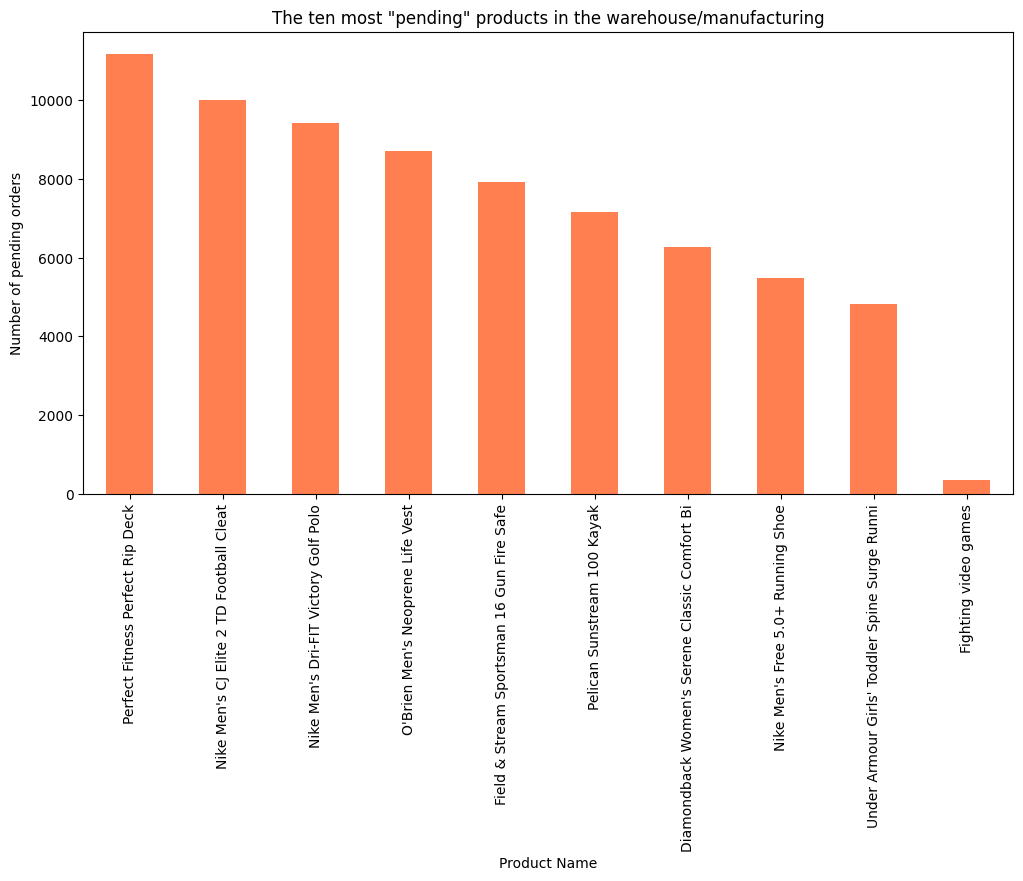

Total 'frozen' sales for the top 5 products:
Product Name
Field & Stream Sportsman 16 Gun Fire Safe        3.167842e+06
Perfect Fitness Perfect Rip Deck                 2.012245e+06
Diamondback Women's Serene Classic Comfort Bi    1.880275e+06
Nike Men's Free 5.0+ Running Shoe                1.650935e+06
Pelican Sunstream 100 Kayak                      1.433128e+06
Name: Sales, dtype: float64


In [8]:
# 1. تصفية الطلبات التي لا تزال تحت المعالجة أو قيد الانتظار
pending_orders = df[df['Order Status'].isin(['PENDING', 'PROCESSING', 'PENDING_PAYMENT'])]

# 2. تحليل المنتجات الأكثر تكراراً في هذه الحالات (Bottleneck Products)
bottleneck_products = pending_orders.groupby('Product Name').size().sort_values(ascending=False).head(10)

# 3. تحليل الربحية الضائعة (قيمة الطلبات المعلقة)
lost_value = pending_orders.groupby('Product Name')['Sales'].sum().sort_values(ascending=False).head(10)

# رسم النتائج
plt.figure(figsize=(12, 6))
bottleneck_products.plot(kind='bar', color='coral')
plt.title('The ten most "pending" products in the warehouse/manufacturing')
plt.ylabel('Number of pending orders')
plt.show()

print("Total 'frozen' sales for the top 5 products:")
print(lost_value.head(5))

1. تحليل "عنق الزجاجة" (The Bottleneck)لاحظ أن المتهمين الخمسة الأوائل في "المبيعات المجمدة" هم منتجات ثقيلة أو ضخمة (خزنة أسلحة، دراجة، قارب كاياك).التشخيص: المشكلة ليست في "التصنيع" (Manufacturing) بالضرورة، بل في تصميم مخطط المستودع (Warehouse Layout) وكفاءة عمليات الالتقاط والتعبئة (Picking & Packing).المنطق: المنتجات الضخمة تتطلب مسارات حركة خاصة ومعدات رفع ثقيلة. إذا كان المستودع مصمماً للمنتجات الصغيرة (مثل الملابس)، فإن وجود "خزنة أسلحة" سيشل الحركة ويؤدي لتراكم الطلبات تحت حالة "Processing" لفترة طويلة.2. منطق الأتمتة والقرار (Automation Decision)بناءً على هذه الأرقام، توصيتي للمدير لن تكون مجرد "شراء آلات"، بل:تطبيق نظام إدارة المستودعات (WMS): لتتبع "إنتاجية عملية الالتقاط" وتحسين مسارات العمال داخل المستودع.الأتمتة الاستراتيجية: إذا كان المنتج يدر ملايين الدولارات ولكنه يعطل السلسلة، فإن الاستثمار في "أنظمة التخزين الآلي" يصبح ضرورة لتقليل الوقت بين طلب العميل وتسليمه.3. السياق الكلي: الربط المالي (Financial Impact)تجميد 3.1 مليون دولار في طلبات معلقة يعني ضياع فرصة استثمار هذا "رأس المال العامل" (Working Capital) في تطوير منتجات جديدة أو سداد ديون الشركة. دورك كمحلل هنا هو حماية "شريان الحياة المالي" للشركة عبر زيادة سرعة التدفق.

**نموذج التنبؤ بمخاطر التأخير (Predictive Analysis)**

المنطق: بدلاً من انتظار حدوث التأخير ثم تقديم خصم (كما فعلنا في المرحلة السابقة)، نريد أن نتوقع أي طلب سيتأخر لحظة دخوله النظام.


سياق البزنس: إذا عرفنا أن الطلب (X) القادم من "المنطقة الشرقية" بوزن "ثقيل" في وقت "موسمي" لديه احتمالية تأخير 90%، يمكننا فوراً تحويله لمورد بديل أو وسيلة شحن أسرع لبناء "المرونة" (Resilience).

In [9]:
# 1. اختيار المتغيرات التي قد تؤثر على خطر التأخير (الارتباط القياسي)
risk_factors = df[['Shipping Mode', 'Order Region', 'Order Item Quantity', 'Product Price', 'Late_delivery_risk']]

# 2. تحويل البيانات النصية إلى أرقام (Label Encoding) لنتمكن من حساب الارتباط
risk_factors_encoded = pd.get_dummies(risk_factors, columns=['Shipping Mode', 'Order Region'])

# 3. حساب مصفوفة الارتباط (Correlation Matrix)
correlation = risk_factors_encoded.corr()['Late_delivery_risk'].sort_values(ascending=False)

print("أقوى العوامل المؤثرة في زيادة مخاطر التأخير:")
print(correlation.head(10))

أقوى العوامل المؤثرة في زيادة مخاطر التأخير:
Late_delivery_risk             1.000000
Shipping Mode_First Class      0.347259
Shipping Mode_Second Class     0.215689
Order Region_Western Europe    0.008611
Order Region_South Asia        0.006111
Order Region_Central Africa    0.006093
Order Region_East of USA       0.003339
Order Region_Southeast Asia    0.003326
Order Region_South of  USA     0.002870
Order Region_Eastern Europe    0.002497
Name: Late_delivery_risk, dtype: float64


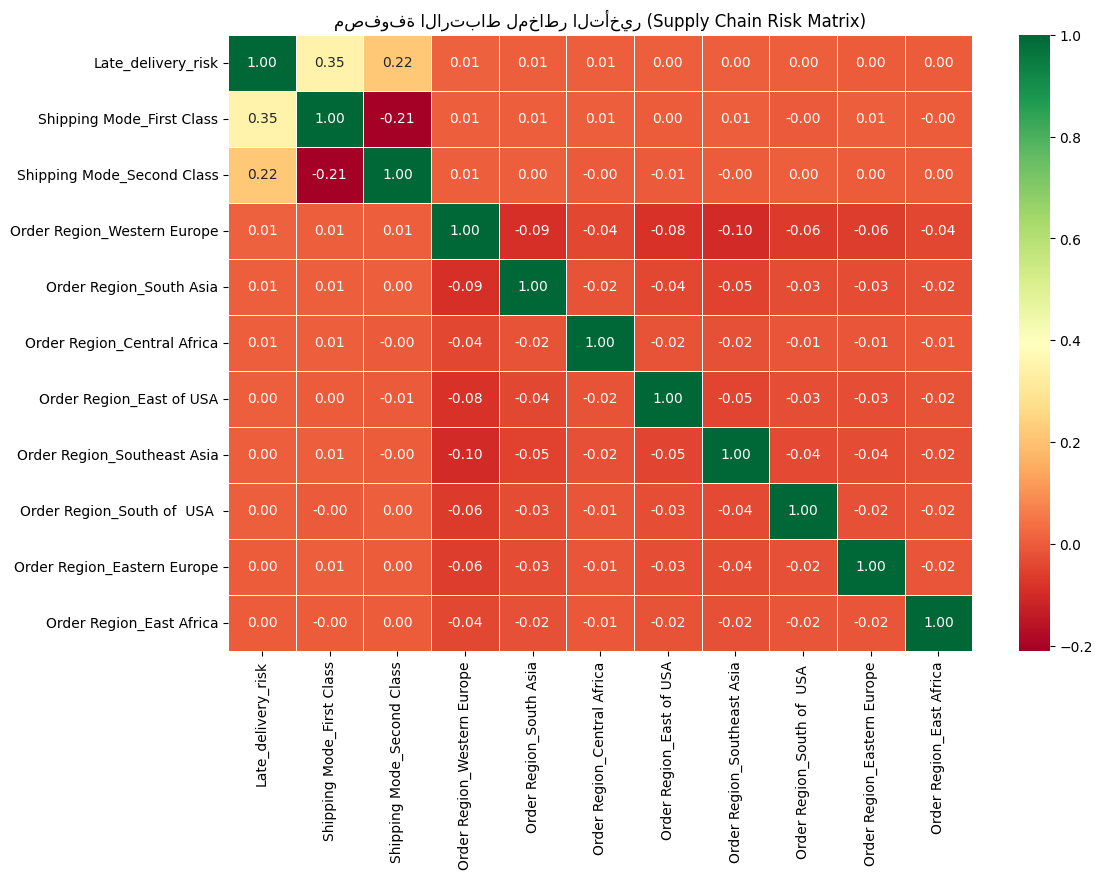

In [10]:
# 1. اختيار أهم 10 عوامل ظهرت في تحليلك السابق
top_factors = correlation.head(11).index
correlation_matrix = risk_factors_encoded[top_factors].corr()

# 2. رسم الخريطة الحرارية
plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='RdYlGn', fmt=".2f", linewidths=0.5)

plt.title('مصفوفة الارتباط لمخاطر التأخير (Supply Chain Risk Matrix)')
plt.show()

ما تم انجازه
Network Health Check (تحليل الأسواق).

Logistics Efficiency (تحليل وسائل الشحن).

Revenue Protection (كشف التغطية بالخصومات).

Warehouse Bottlenecks (المنتجات المجمدة).

Risk Prediction (بناء نموذج الارتباط).